## UBA - CEIA
### Visión por Computadora I - Cohorte 23
#### Trabajo Práctico N°1
#### Alumna: Federica Pavese - a2321

<hr>

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [2]:
%matplotlib inline
#%matplotlib qt

### PARTE 1

1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación

In [3]:
## FUNCIÓN QUE IMPLEMENTA WHITE-PATCH

def white_patch(img): 
    
    # canales RGB
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]
    
    # máximos
    Rmax = np.max(R)
    Gmax = np.max(G)
    Bmax = np.max(B)
    
    # White-Patch por canal
    R_wp = R / Rmax * 255
    G_wp = G / Gmax * 255
    B_wp = B / Bmax * 255
    
    # aplico White-Patch a la imagen
    img_wp = np.stack((R_wp, G_wp, B_wp), axis=2)
    img_wp = np.uint8(img_wp)

    return img_wp


In [4]:
## FUNCIÓN QUE MUESTRA CÓMO SE ESCALARON LOS CANALES

def tabla_white_patch(img):

    # canales RGB
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    # máximos
    Rmax = np.max(R)
    Gmax = np.max(G)
    Bmax = np.max(B)

    # factores de escala
    R_escala = 255 / Rmax
    G_escala = 255 / Gmax
    B_escala = 255 / Bmax

    data = {
        "Canal": ["R", "G", "B"],
        "Max original": [Rmax, Gmax, Bmax],
        "Factor de escala": [R_escala, G_escala, B_escala],
        "Valor": [
            int(100 * R_escala),
            int(100 * G_escala),
            int(100 * B_escala)
        ]
    }

    tabla = pd.DataFrame(data)
    display(tabla)

2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White Patch

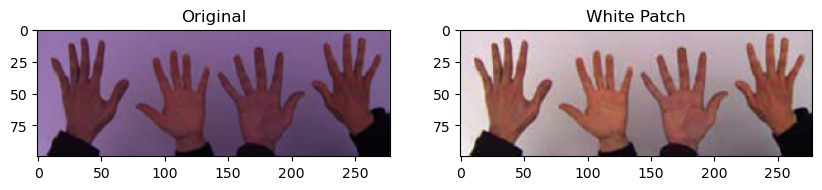

,Canal,Max original,Factor de escala,Valor
0,R,165,1.545455,154
1,G,138,1.847826,184
2,B,200,1.275000,127


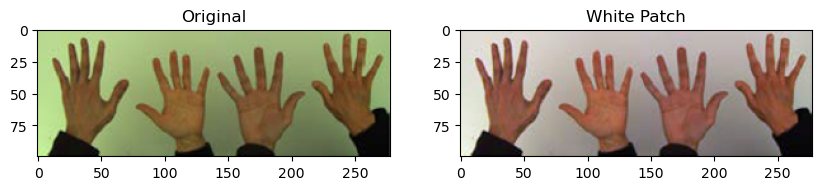

,Canal,Max original,Factor de escala,Valor
0,R,210,1.214286,121
1,G,250,1.020000,102
2,B,171,1.491228,149


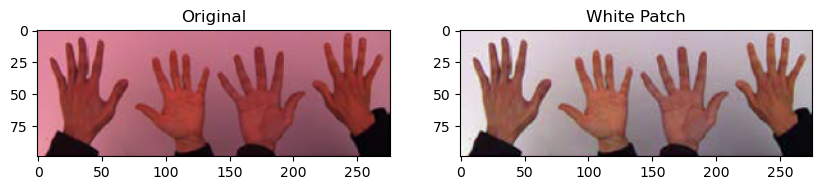

,Canal,Max original,Factor de escala,Valor
0,R,247,1.032389,103
1,G,157,1.624204,162
2,B,175,1.457143,145


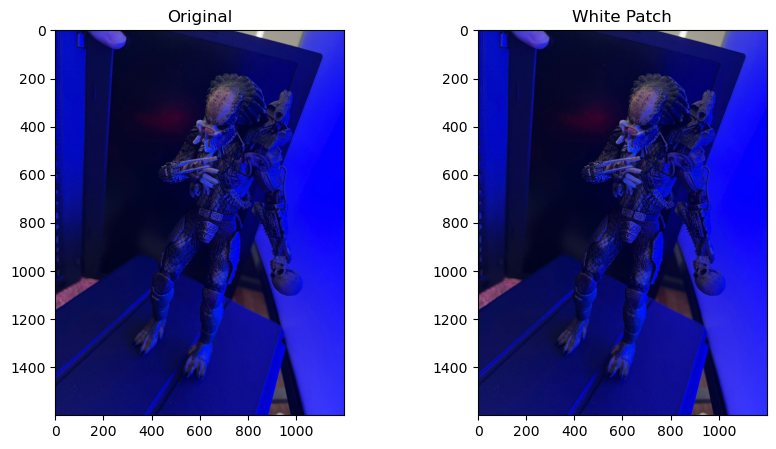

,Canal,Max original,Factor de escala,Valor
0,R,255,1.0,100
1,G,255,1.0,100
2,B,255,1.0,100


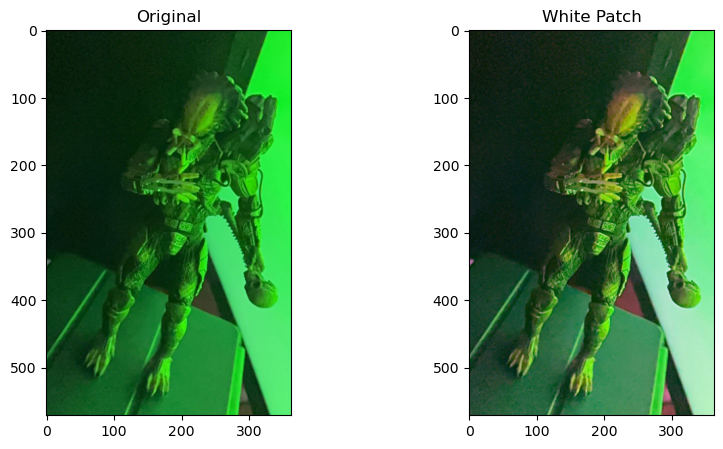

,Canal,Max original,Factor de escala,Valor
0,R,126,2.023810,202
1,G,252,1.011905,101
2,B,155,1.645161,164


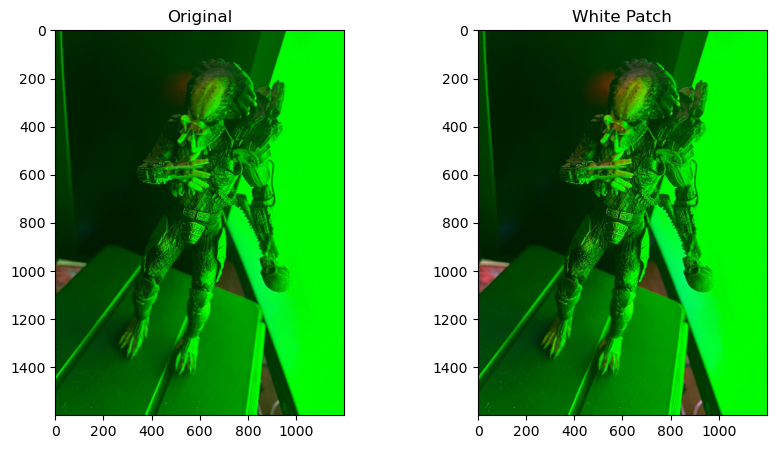

,Canal,Max original,Factor de escala,Valor
0,R,170,1.500000,150
1,G,255,1.000000,100
2,B,172,1.482558,148


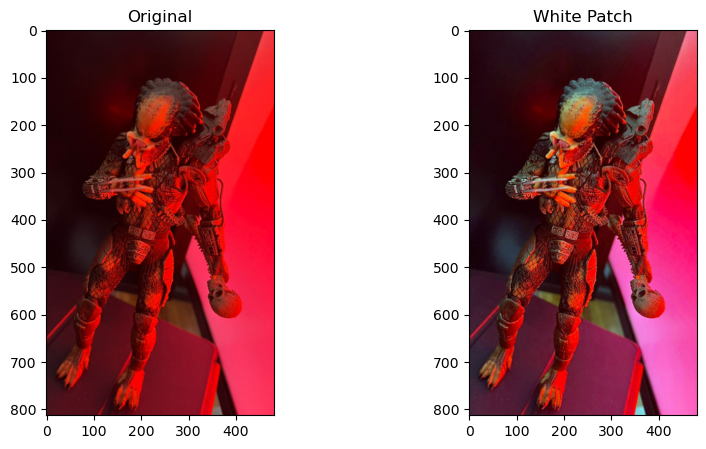

,Canal,Max original,Factor de escala,Valor
0,R,255,1.000000,100
1,G,134,1.902985,190
2,B,122,2.090164,209


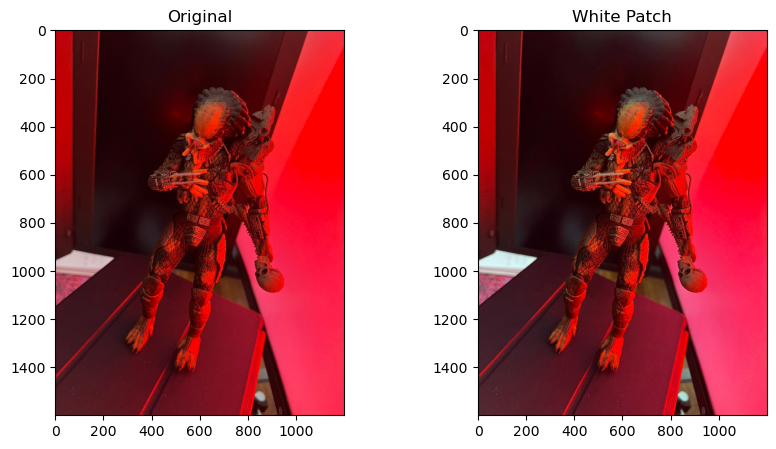

,Canal,Max original,Factor de escala,Valor
0,R,255,1.000000,100
1,G,201,1.268657,126
2,B,203,1.256158,125


In [6]:
directorio = "white_patch"

for archivo in os.listdir(directorio):

    if archivo.endswith(".png") or archivo.endswith(".jpg"):

        ruta_archivo = os.path.join(directorio, archivo)

        img = cv.imread(ruta_archivo)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        # aplico la función
        img_wp = white_patch(img)

        # muestro original y modificada
        plt.figure(figsize=(10,5))

        plt.subplot(121)
        plt.title("Original")
        plt.imshow(img)

        plt.subplot(122)
        plt.title("White Patch")
        plt.imshow(img_wp)

        plt.show()     
        tabla_white_patch(img)
        

Análisis de los resultados

| Imagen | Original | White-Patch | Resultado |
|-----------|--------|------|--------|
| test_blue.png | predomina el canal B | B menos escalado que R y G | imagen equilibrada |
| test_green.png | predomina el canal G | G menos escalado que R y B | imagen equilibrada |
| test_red.png | predomina el canal R | R menos escalado que B y G | imagen equilibrada |
| wp_blue.jpg | canal B muy predominante | no se escala ningún canal porque Rmax = Gmax = Bmax = 255 | el algoritmo no modifica la imagen, porque no existe un píxel blanco neutro que pueda utilizarse como referencia |
| wp_green.jpg | canal G muy predominante | G se escala muy poco mientras que R y B aumentan más | la imagen se ve levemente equilibrada, pero sigue predominando el verde |
| wp_green2.jpg | canal G muy predominante | G no se escala, mientras que R y B sí | la imagen se ve levemente equilibrada, pero sigue predominando el verde |
| wp_red.jpg | canal R muy predominante | R no se escala, mientras que G y B sí | la imagen se ve levemente equilibrada, aunque sigue predominando el rojo |
| wp_red2.jpg | canal R muy predominante | R no se escala, mientras que G y B sí, pero poco porque ya están altos | la imagen se ve muy levemente equilibrada, y sigue predominando el rojo |


### PARTE 2

1. Para las imágenes <i>img1_tp.png</i> y <i>img2_tp.png</i> leerlas con OpenCV en escala de grises y visualizarlas

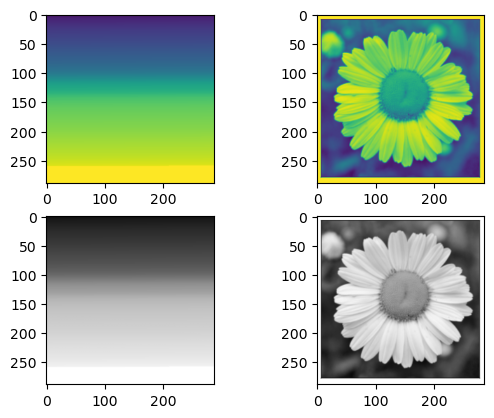

In [7]:
img1_tp = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2_tp = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

plt.subplot(221)
plt.imshow(img1_tp)
plt.subplot(222)
plt.imshow(img2_tp)

# agrego colormap para verlas en escala de grises
plt.subplot(223)
plt.imshow(img1_tp, cmap='gray')
plt.subplot(224)
plt.imshow(img2_tp, cmap='gray')

plt.show()

2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

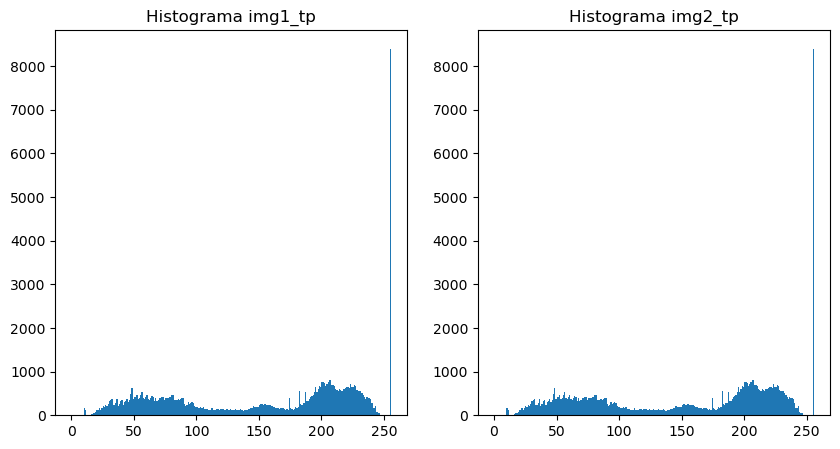

In [8]:
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.hist(img1_tp.ravel(), bins=256, range=[0,256])
plt.title("Histograma img1_tp")

plt.subplot(122)
plt.hist(img2_tp.ravel(), bins=256, range=[0,256])
plt.title("Histograma img2_tp")

plt.show()

Ambos histogramas son muy similares (sino idénticos), porque la distribución de intensidades en ambas imágenes es muy similar.
El histograma muestra la distribución de intensidades, no la estructura espacial de la imagen, por eso coinciden aunque las imágenes sean completamente diferentes.
   
Si quisiéramos entrenar un modelo de clasificación o detección de imágenes, dependiendo el caso podrían servir o no. 
Si nos importa la forma de la imagen, estos histogramas solos no serían features adecuados para entrenar. Necesitaríamos más información que describa las imágenes, como formas, bordes, texturas, etc.
Si quisiéramos entrenar un modelo que distinga, por ejemplo, si la imagen es diurna o nocturna, entonces podrían servir.
